# Laboratorio de regresión - 3

## Análisis exploratorio de datos y limpieza

|                |   |
:----------------|---|
| **Nombre**     | Claudio Alejo Encarnación Martínez |
| **Fecha**      |  4 septiembre 2026 |
| **Expediente** |  750597 |

En los laboratorios y clases anteriores se ha visto que el modelo de regresión propuesto puede ser cualquier combinación lineal de factores independientes. Por lo tanto hay un número infinito de posibles modelos de regresión teóricos. ¿Cómo podemos deducir qué tipo de modelo podríamos necesitar?

- **RESPUESTA**

Primero habría que analizar nuestros datos, entender cómo se componen y se relacionan, para así poder proponer un modelo que se adapte a estos y los explique de mejor manera. Si no obtenemos un buen resultado, planteamos otro modelo que se pueda adaptar, un poco de prueba y error.

### EDA

El primer paso antes de poder proponer un modelo para predecir datos es entender el conjunto de datos con el que se está trabajando.
- ¿Cuántas muestras tiene?
- ¿Cuántos factores tiene?
- ¿Quién o qué hizo la recolección de las observaciones?
- ¿Cómo se hizo el muestreo?
- ¿En qué año se hicieron las observaciones?
- ¿En dónde se realizaron las observaciones?

El propósito de un análisis exploratorio de datos (EDA - Exploratory Data Analysis) es entender la naturaleza de los datos, comprender las relaciones existentes entre las variables para poder realizar hipótesis sobre cómo se relaciona la variable dependiente con las independientes.

#### Ejercicio 1: Dataset

Utiliza el dataset "Heart Prediction Dataset (Quantum)". Carga los datos y revisa qué factores contiene.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('/Users/claudioalejoencarnacionmartinez/Documents/SEMESTRE OTOÑO 2026/LAB APRENDIZAJE ESTADÍSTICO/LABORATORIO-DE-APRENDIZAJE-ESTAD-STICO/Heart Prediction Quantum Dataset.csv')
df.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
0,68,Hombre,105.00,191,107,1
1,58,Mujer,97.00,249,89,0
2,44,Mujer,93.00,190,82,1
3,72,Hombre,93.00,183,101,1
4,37,Mujer,145.00,166,103,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            500 non-null    int64
 1   Gender         500 non-null    str  
 2   BloodPressure  500 non-null    str  
 3   Cholesterol    500 non-null    int64
 4   HeartRate      500 non-null    int64
 5   HeartDisease   500 non-null    int64
dtypes: int64(4), str(2)
memory usage: 23.6 KB


In [4]:
df.tail()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
495,34,Mujer,126.00,292,116,0
496,41,Mujer,164.00,248,114,0
497,45,Hombre,159.00,175,75,0
498,55,Mujer,107.00,157,101,1
499,55,Mujer,174.00,249,89,0


**RESPUESTA**

Contiene datos médicos de personas: 
1. Edad (cuantitativo, numérico entero, no ordinal)
2. Género (cualitativo, se puede reinterpretar como booleano ¿Es hombre? Sí/No, no ordinal)
3. Presión arterial (cuantitativo, numérico float, no ordinal)
4. Colesterol (cuantitativo, numérico entero, no ordinal)
5. Ritmo cardiaco (cualitativo, booleano, Si tienen o no una enfermedad cardiaca)

Para cada factor, escribe qué significa cada variable.
- ¿Qué tipo de datos se observaron?
    - Numéricos
        - Enteros
        - Flotantes
    - Categóricos
        - Ordinales
        - No ordinales
- ¿Qué rango de valores sería esperado que contuviera cada factor? E.g. No esperaría encontrar un valor de Age de $-4$.

Investiga los valores esperados para variables que no entiendas como BloodPressure, Cholesterol, etc.

- **RESPUESTA**
1. Age: 0–120 años
2. Gender: Hombre / Mujer
3. BloodPressure: 0–300 mmHg
4. Cholesterol: 0–600 mg/dL
5. HeartRate: 0–250 bpm
6. HeartDisease: 0–1

A partir de lo investigado, describe el dataset con tus palabras.

- **RESPUESTA**

Es un dataset de datos médicos (específicamente relacionados a salud cardiaca) de personas variadas. Puedo intuir que podríamos elaborar un modelo que usando los datos desde Edad hasta HeartRate podríamos sacar conclusiones sobre la variable HeartDisease.

#### Ejercicio 2: Factores

Ahora que se tiene un mejor entendimiento del dataset y de los valores que podría tener cada variable, es momento de revisar que las observaciones en el dataset estén dentro de ese rango esperado.

Crea un histograma para cada uno de los factores para ver el rango de los valores medidos y su distribución. 

- **RESPUESTA**

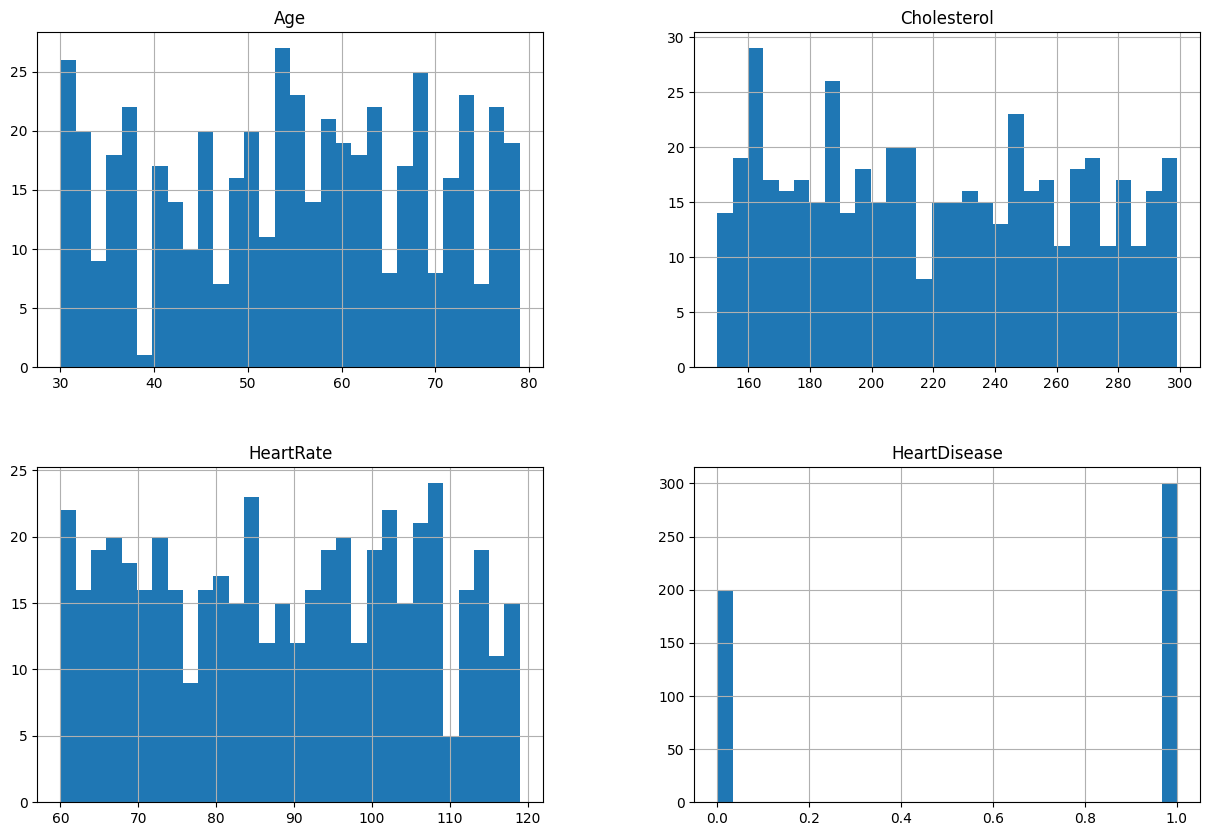

In [ ]:
#histograma para cada uno de los factores para ver el rango de los valores medidos y su distribución
df.hist(bins=30, figsize=(15, 10))
plt.show()


¿Parecen correctas estas distribuciones? ¿Qué valores atípicos encontraste? ¿Alguna inconsistencia? ¿Los problemas encontrados podrían ser casos reales?

- **RESPUESTA**

A simple vista creo poder asegurar que parecen datos reales y no presentan inconsistencias o valores atípicos, todos se encuentran dentro de rangos reales según lo que investigué antes

#### Ejercicio 3: Limpieza

Es muy común que haya errores al registrar observaciones. Puede ser que personas diferentes hayan registrado datos con un estilo diferente, o que haya habido un error de dedo. También podrían haber registros duplicados, o datos faltantes.

Por ejemplo, la columna BloodPressure tiene dos estilos diferentes para el punto decimal (americano y europeo).

Utiliza `pandas.Series.str.replace` para cambiar el punto decimal de europeo a americano en la columna de BloodPressure. Después, cambia el tipo de dato de la columna a numérico. Dibuja el histograma de la variable corregida.

- **RESPUESTA**

In [6]:
#Cambiar el punto decimal de europeo a americano en la columna de BloodPressure
df['BloodPressure'] = df['BloodPressure'].str.replace(',', '.').astype(float)
df['BloodPressure'].head()

0    105.0
1     97.0
2     93.0
3     93.0
4    145.0
Name: BloodPressure, dtype: float64

La columna Gender tiene también errores de dedo y de estilo. Utiliza `pandas.Series.unique()` para encontrar las formas diferentes en las que se escribió "Hombre" y "Mujer".

- **RESPUESTA**

In [7]:
df['Gender'].unique()

<StringArray>
['Hombre   ',     'Mujer',     'ombre',     'mujer',     'MUjer',     'MUJER',
    'Mujer{',   'Hombre}',    'Hombre']
Length: 9, dtype: str

La diferencia entre una mayúscula y minúscula para una computadora tiene que ver con la tabla ASCII. Para evitar esta variación utiliza `pandas.Series.str.lower()` para convertir todos las mayúsculas en minúsculas. Guarda el resultado en una variable auxiliar. Utiliza `unique()` una vez más para ver el resultado.

- **RESPUESTA**

In [8]:
df['Gender'] = df['Gender'].str.lower()
df['Gender'].unique()

<StringArray>
['hombre   ', 'mujer', 'ombre', 'mujer{', 'hombre}', 'hombre']
Length: 6, dtype: str

Observamos que hay errores como espacios en blanco o errores de dedo. Utiliza `pandas.Series.str.rstrip("xxx")` para limpiar los caracteres indeseados.

- **RESPUESTA**

In [13]:
#Eliminar espacios en blanco al final de los valores de la columna Gender
df['Gender'] = df['Gender'].str.rstrip("   ")
df['Gender'].unique()

<StringArray>
['hombre', 'mujer']
Length: 2, dtype: str

In [11]:
df['Gender'] = df['Gender'].str.rstrip("}",).str.rstrip("{")
df['Gender'].unique()

<StringArray>
['hombre   ', 'mujer', 'ombre', 'hombre']
Length: 4, dtype: str

Utiliza un filtro para corregir el typo de la 'h' faltante para la categoría "hombre".

- **RESPUESTA**

In [12]:
#Utiliza un filtro para corregir el typo de la 'h' faltante para la categoría "hombre"
df['Gender'] = df['Gender'].replace('ombre', 'hombre')
df['Gender'].unique()

<StringArray>
['hombre   ', 'mujer', 'hombre']
Length: 3, dtype: str

Asigna "hombre"=1 y "mujer"=0 (Ojo con los tipos de dato. Considera que 0 es diferente a "0").

- **RESPUESTA**

In [14]:
#Convertir columna Gender a valor booleano (Hombre = 1, Mujer = 0)
df['Gender'] = df['Gender'].map({'hombre': 1, 'mujer': 0})
df.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
0,68,1,105.0,191,107,1
1,58,0,97.0,249,89,0
2,44,0,93.0,190,82,1
3,72,1,93.0,183,101,1
4,37,0,145.0,166,103,1


Reescribe el resultado en el dataset original.

- **YA GUARDADO EN CADA PASO**

In [15]:
df.head(10)

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
0,68,1,105.0,191,107,1
1,58,0,97.0,249,89,0
2,44,0,93.0,190,82,1
3,72,1,93.0,183,101,1
4,37,0,145.0,166,103,1
5,50,1,114.0,271,73,0
6,68,1,156.0,225,73,1
7,48,0,156.0,236,61,0
8,52,0,116.0,266,114,0
9,40,1,121.0,255,96,0


Para asegurarnos que no haya duplicados, utiliza `pd.DataFrame.drop_duplicates()`

- **RESPUESTA**

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            500 non-null    int64  
 1   Gender         500 non-null    int64  
 2   BloodPressure  500 non-null    float64
 3   Cholesterol    500 non-null    int64  
 4   HeartRate      500 non-null    int64  
 5   HeartDisease   500 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 23.6 KB


In [18]:
df = df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            500 non-null    int64  
 1   Gender         500 non-null    int64  
 2   BloodPressure  500 non-null    float64
 3   Cholesterol    500 non-null    int64  
 4   HeartRate      500 non-null    int64  
 5   HeartDisease   500 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 23.6 KB


Para los valores faltantes se podría imputar, pero por ahora sólo elimínalos (si es que hay) con `pd.DataFrame.dropna()`

- **RESPUESTA**

In [19]:
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            500 non-null    int64  
 1   Gender         500 non-null    int64  
 2   BloodPressure  500 non-null    float64
 3   Cholesterol    500 non-null    int64  
 4   HeartRate      500 non-null    int64  
 5   HeartDisease   500 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 23.6 KB


#### Ejercicio 4: Verificación

Ahora que entendemos qué significan nuestras variables y que las limpiamos, vuelve a generar histogramas para cada variable.

- **RESPUESTA**

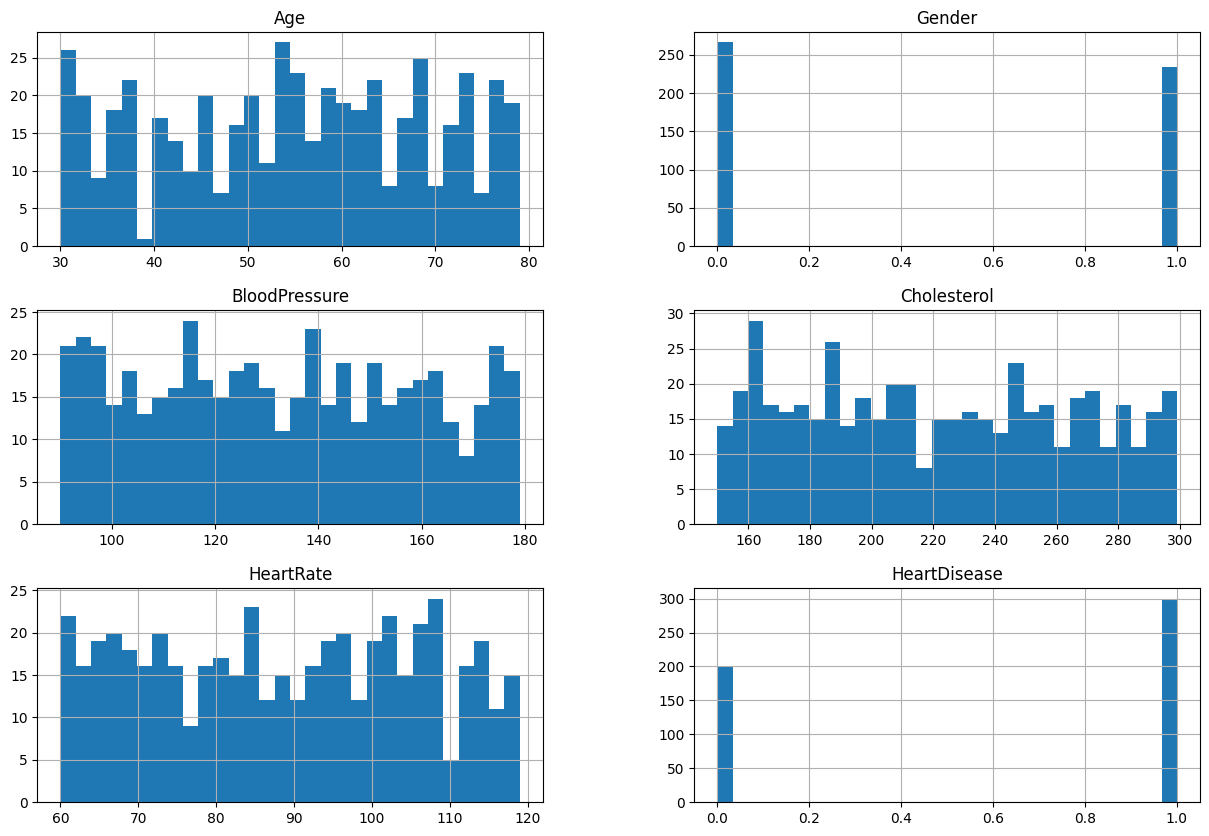

In [20]:
#histograma para cada uno de los factores para ver el rango de los valores medidos y su distribución
df.hist(bins=30, figsize=(15, 10))
plt.show()

Encuentra la siguiente información para las variables numéricas:
- media
- mediana
- desviación estándar
- mínimo
- máximo

Genera un diagrama de caja para cada una. ¿Consideras que hay valores atípicos (outliers)?

- **RESPUESTA**

In [21]:
df.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,1.000000


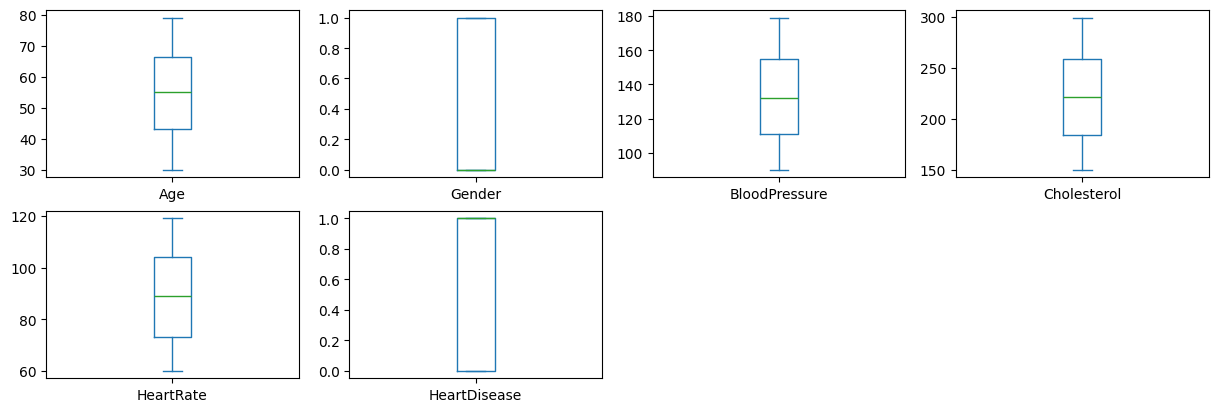

In [22]:
#Generar diagrama de caja para cada una de las variables numéricas
df.plot(kind='box', subplots=True, layout=(4,4), figsize=(15,10), sharex=False, sharey=False)
plt.show()

No se encuentra ningún valor atípico (saldrían en la gráfica como puntos en los extremos)

Encuentra la siguiente información para las variables categóricas:
- tabla de frecuencias
- valores únicos

- **RESPUESTA**

In [24]:
#Tabla de frecuencias para la variable Gender y HeartDisease
gender_counts = df['Gender'].value_counts()
heart_disease_counts = df['HeartDisease'].value_counts()
gender_counts, heart_disease_counts

(Gender
 0    266
 1    234
 Name: count, dtype: int64,
 HeartDisease
 1    300
 0    200
 Name: count, dtype: int64)

In [25]:
#Valores únicos de la variable HeartDisease y Gender
df['HeartDisease'].unique(), df['Gender'].unique()

(array([1, 0]), array([1, 0]))

## Referencia

Dataset original tomado de: https://www.kaggle.com/datasets/shantanugarg274/heart-prediction-dataset-quantum